<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-CastroCano/Evaluacion2/CastroCano/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Evaluación No. 2***

Programación Científica 2026-1 · Universidad Nacional de Colombia

**Estudiante:** Maria Fernanda Castro Cano

**Correo:** marcastroca@unal.edu.co

**CC:** 100041[6767]

In [88]:
#LateX, importación de librerías necesarias y configuraciones

!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import jax
import jax.numpy as jnp
from jax import grad, jit

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print("Configuración OK")


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

# **Carga y exploración de los datos** ⚛


In [89]:
#Carga de datos personalizados desde el repo
# URL RAW del archivo .npz
url_datos = "https://raw.githubusercontent.com/manubastidas/programacionCientifica/eval2-CastroCano/Evaluacion2/CastroCano/datos_6767.npz"

# Descargar archivo
!wget -q {url_datos} -O datos_6767.npz

# Cargar datos
datos = np.load("datos_6767.npz")

# Ver qué contiene el archivo
print("Variables en el archivo:")
print(datos.files)


Variables en el archivo:
['X', 'y', 't', 'meta']


In [90]:
#Inspeccionar el contenido del .npz para conocer las variables disponibles y sus dimensiones.

for key in datos.files:
    print(f"{key}: {datos[key].shape}")


X: (30, 256)
y: (30,)
t: (256,)
meta: (3,)


**Explicación:**

*   X: Matriz de datos principal (dimensiones) (30, 256). Tiene 30 observaciones cada una con 256 puntos.
*   y: Vector de dimensiones (30,). Contiene etiqueta por cada muestra.
*   t: Vector de dimensiones (256,). Es la variable independiente que coincide en todas las muestras.
*   meta: Vector de dimensiones (3,). Contiene más información del experimento

Por lo cual cada fila $X[i]$ representa una señal definida sobre el eje t con etiqueta $y[i]$.





In [91]:
X = datos["X"]
y = datos["y"]
t = datos["t"]

print("Número de muestras:", X.shape[0])
print("Número de puntos por muestra:", X.shape[1])
print("Número de etiquetas únicas:", len(np.unique(y)))

Número de muestras: 30
Número de puntos por muestra: 256
Número de etiquetas únicas: 3


# **Visualización de los datos** ⚛

Para comprender mejor las estructuras de los datos se visualizan algunas señales representativas de cada régimen. De acuerdo al enunciado cada señal es una suma de cosenos con distintas frecuencias y las `y` clasifican el régimen que puede ser sin dispersión (0), dispersión intermedia (1) ó dispersión fuerte (2).

Se esperaría que a mayor régimen las señales presentan oscilaciones más rápidas.

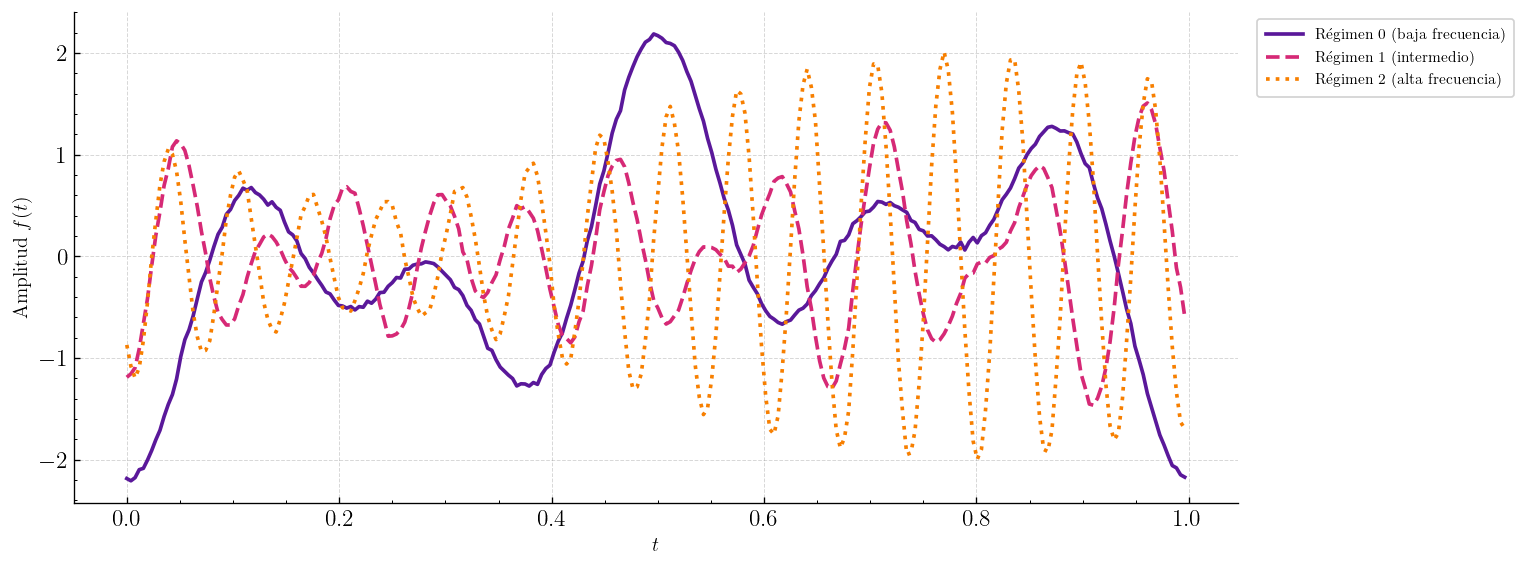

In [92]:
# Selección de una señal por régimen
idx0 = np.where(y == 0)[0][0]
idx1 = np.where(y == 1)[0][0]
idx2 = np.where(y == 2)[0][0]

x0 = X[idx0]
x1 = X[idx1]
x2 = X[idx2]

# Paleta violeta / magent / naranja / tonos que se me parecen a magma
colores = ["#5A189A", "#D62976", "#F77F00"]
estilos = ["-", "--", ":"]  # sólido-guiones-puntos
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(t, x0, label="Régimen 0 (baja frecuencia)",
        color=colores[0], linestyle=estilos[0], linewidth=2.2)
ax.plot(t, x1, label="Régimen 1 (intermedio)",
        color=colores[1], linestyle=estilos[1], linewidth=2.2)
ax.plot(t, x2, label="Régimen 2 (alta frecuencia)",
        color=colores[2], linestyle=estilos[2], linewidth=2.2)

ax.set_xlabel(r"$t$", fontsize=12)
ax.set_ylabel(r"Amplitud $f(t)$", fontsize=12)

ax.grid(True, alpha=0.3, linewidth=0.6)

# Leyenda
ax.legend(
    fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    framealpha=0.9,
    borderpad=0.6,
    handlelength=2.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


Note que:

- En el régimen 0 la señal presenta oscilaciones suaves (frecuencias bajas).

- En el régimen 1 aparecen oscilaciones más rápidas (mayor presencia de frecuencias intermedias).

- En el régimen 2 la señal exhibe oscilaciones más oscilatorias (asociadas a frecuencias altas)

Esto es consistente con la relación:

$$
\omega(k) = \sqrt{c^2 k^2 + \mu^2}
$$

puesto que al aumentar $\mu$, las frecuencias aumentan y ello produce
señales más oscilatorias.

Esta observación es clave, justamente sugiere que una base de Fourier
podría representar de manera eficiente estas señales.

# **Capa Fourier ⚛**

Se construye una matriz $W_1$ cuyas filas corresponden a funciones
seno y coseno de distintas frecuencias.

Esta matriz permitirá proyectar las señales al dominio de frecuencias.

In [93]:
def construir_W1(K, t):
    N = len(t)
    dt = t[1] - t[0]
    T = N * dt

    filas = []
    for k in range(1, K + 1):
        filas.append(np.sin(2 * np.pi * k * t / T))
        filas.append(np.cos(2 * np.pi * k * t / T))

    W1 = np.array(filas)
    return W1

# Construcción
K = 15
W1 = construir_W1(K, t)
print("Dimensión de W1:", W1.shape)

Dimensión de W1: (30, 256)


La matriz $W_1 \in \mathbb{R}^{2K \times 256}$ está compuesta por funciones
seno y coseno de diferentes frecuencias. Para cada frecuencia $ k $, se incluyen dos componentes:
  - $ \sin(2\pi k t) $
  - $ \cos(2\pi k t) $

Esto explica por qué la matriz tiene $2K$ filas.

Para verificar que la matriz $ W_1 $ captura el contenido frecuencial de las
señales, se compara su proyección con la Transformada de Fourier obtenida mediante `np.fft.fft`.

**NOTA.** FFT es Fast Fourier Transform (Transformada Rápida de Fourier).

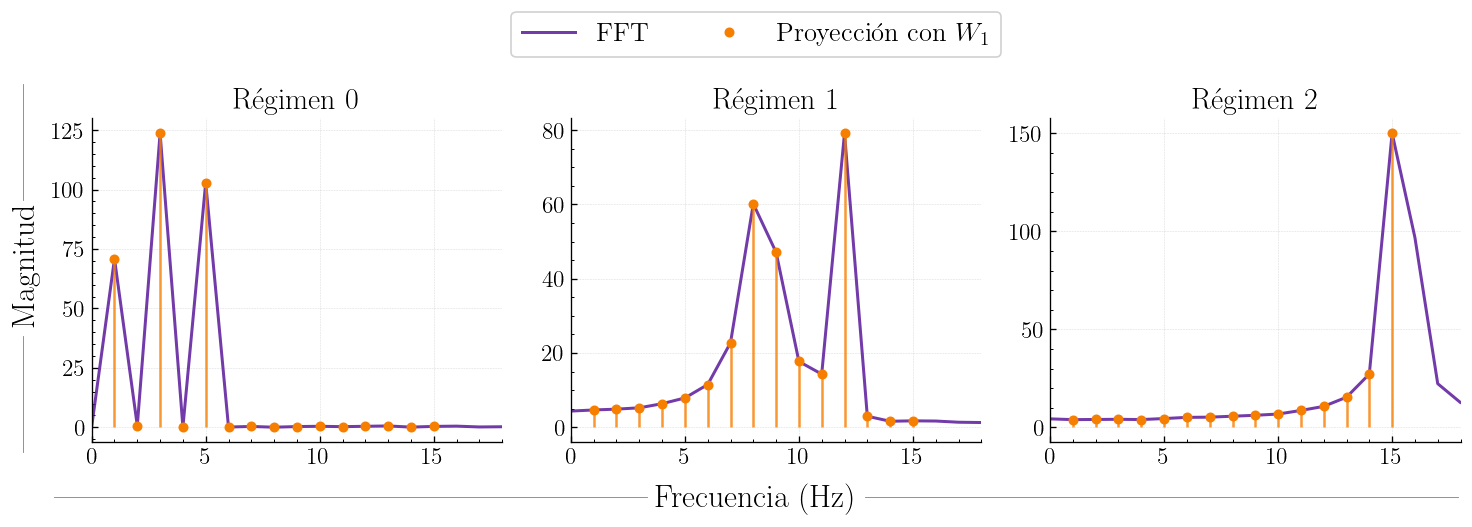

In [214]:
# señal representativa por régimen
indices = [np.where(y == i)[0][0] for i in range(3)]
regimenes = [0, 1, 2]

dt = t[1] - t[0]
freqs = np.fft.fftfreq(256, d=dt)
mask = freqs >= 0
freqs_k = np.arange(1, K + 1)
color_fft = "#5A189A"
color_w1  = "#F77F00"

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, idx, regimen in zip(axes, indices, regimenes):
    x = X[idx]

    # Proyección con W1 y su magnitud
    proj_W1 = W1 @ x
    proj_mag = np.sqrt(proj_W1[0::2]**2 + proj_W1[1::2]**2)

    # FFT de referencia
    fft_mag = np.abs(np.fft.fft(x))

    # Curva FFT
    ax.plot(freqs[mask], fft_mag[mask], label="FFT",
            color=color_fft, linewidth=1.8, alpha=0.85)

    # Proyección W1
    markerline, stemlines, _ = ax.stem(freqs_k, proj_mag, basefmt=" ")
    markerline.set_color(color_w1)
    markerline.set_markersize(5)
    stemlines.set_color(color_w1)
    stemlines.set_alpha(0.8)
    markerline.set_label(r"Proyección con $W_1$")

    # Configuración de cada panel
    ax.set_title(f"Régimen {regimen}")
    ax.set_xlim(0, K + 3)
    ax.grid(True)

plt.tight_layout(rect=[0.06, 0.06, 1, 0.93])

fig.supxlabel("Frecuencia (Hz)", x=0.53, y=0.025)
fig.supylabel("Magnitud", x=0.053, y=0.52)

# Leyenda
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.53, 1.05),
           ncol=2, frameon=True, framealpha=0.9)

color_linea = "gray"
lw_linea = 0.5

#Líneas para ser más explíicitas con los ejes
fig.add_artist(plt.Line2D([0.06, 0.06], [0.65, 0.88],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.06, 0.06], [0.15, 0.38],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))

fig.add_artist(plt.Line2D([0.08, 0.46], [0.06, 0.06],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.6, 0.98], [0.06, 0.06],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))

plt.show()

Los picos obtenidos con $W_1$ coinciden con los picos de la FFT
en las primeras frecuencias y ello indica que ambas representaciones contienen
la misma información en esos modos. La diferencia es que la FFT entrega todas las frecuencias posibles, mientras que $W_1$ solo considera las primeras $K$. En otras palabras $W_1$ actúa como una versión 'truncada' de la transformada de Fourier.

**Energía media**

Para responder a la pregunta: ¿qué tan "fuerte" es cada señal? Se remite al concepto de *energía* y es simplemente la suma de los valores de la señal al cuadrado:

$$E = \sum_n x_n^2$$

Si en vez de la suma total se toma el promedio, entonces se obtiene **energía media**:

$$\bar E = \frac{1}{N}\sum_n x_n^2$$

Lo interesante es que la misma energía se puede calcular de dos maneras distintas y da casi el mismo número: sumando la señal en el tiempo, como lo anterior, o sumando sus componentes de frecuencia (los coeficientes de Fourier). A eso se le conoce como **teorema de Parseval**:

$$\sum_{n} x_n^2 = \frac{1}{N}\sum_k |X_k|^2$$

Así, no importa si se mira la señal "en el tiempo" o "en frecuencia", la energía que contiene es la misma. Esto es demasiado útil porque si se quisiera quedar solo con algunas frecuencias (las más importantes) en vez de con la señal completa se podría usar la energía para saber qué tanto se pierde sin tener que reconstruir la señal cada vez para comparar.

In [20]:
energia_media = (X**2).mean()

print(f"Energía media: {energia_media:.3f}")

Energía media: 0.707
